# Analytic DRT Functions

This notebook implements analytic expressions for the Distribution of Relaxation Times (DRT) and impedance for the Havriliak-Negami (HN) model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import NyquistPlot, DRTPlot, ResidualsPlot, PolarisationPlot
from redoxed.impedance import EISData, DRTData
from redoxed.dc import PolarisationData

from redoxed import config
config.set_latex_mode(True)  

%matplotlib inline

## Havriliak-Negami Model

The Havriliak-Negami (HN) model provides analytic expressions for both the impedance and the DRT.

In [2]:
def HN_Z(
    omega: float | np.ndarray,
    Z0: float,
    tau0: float,
    alpha: float,
    beta: float
) -> complex | np.ndarray:
    """
    Calculate the Havriliak-Negami impedance.

    Parameters
    ----------
    omega : float or np.ndarray
        Angular frequency (rad/s)
    Z0 : float
        Characteristic impedance magnitude (Ohm)
    tau0 : float
        Characteristic time constant (s)
    alpha : float
        Shape parameter (0 < alpha <= 1)
        Controls the symmetric broadening of the peak
    beta : float
        Shape parameter (0 < beta <= 1)
        Controls the asymmetric broadening of the peak

    Returns
    -------
    complex or np.ndarray
        Complex impedance Z(ω)

    Notes
    -----
    Implements equation for Havriliak Negami impedance:
    Z(ω) = Z0 / (1 + (jωτ0)^α)^β
    From:
    Boukamp, B. A.; Rolle, A. "Use of a Distribution Function of Relaxation Times (DFRT) in Impedance Analysis of SOFC Electrodes." Solid State Ionics 2018, 314, 103–111. https://doi.org/10.1016/j.ssi.2017.11.021
    See Eq. 8. 

    Special cases:
    - α=1, β=1: Debye (single time constant) AKA RC element
    - α<1, β=1: Cole-Cole (symmetric peak broadening) AKA RQ or ZARC element
    - α=1, β<1: Cole-Davidson (asymmetric peak broadening)
    - α=0.5, β=1: Gerischer element (semi-infinite diffusion)
    """
    # Enforce parameter bounds
    if not (0 < alpha <= 1):
        raise ValueError("alpha must be in (0, 1]")
    if not (0 < beta <= 1):
        raise ValueError("beta must be in (0, 1]")
    # Convert to numpy array for consistent handling
    omega = np.asarray(omega)

    # Calculate (jωτ0)^α
    jwt0_alpha = (1j * omega * tau0) ** alpha

    # Calculate Z(ω) = Z0 / (1 + (jωτ0)^α)^β
    Z = Z0 / (1 + jwt0_alpha) ** beta

    return Z


In [3]:
def HN_DRT(
    tau: float | np.ndarray,
    Z0: float,
    tau0: float,
    alpha: float,
    beta: float
) -> float | np.ndarray:
    """
    Calculate the Havriliak-Negami Distribution of Relaxation Times (DRT).
    
    Parameters
    ----------
    tau : float or np.ndarray
        Time constant(s) (s)
    Z0 : float
        Characteristic impedance magnitude (Ohm)
    tau0 : float
        Characteristic time constant (s)
    alpha : float
        Shape parameter (0 < alpha <= 1)
        Controls the symmetric broadening of the peak
    beta : float
        Shape parameter (0 < beta <= 1)
        Controls the asymmetric broadening of the peak
        
    Returns
    -------
    float or np.ndarray
        DRT γ(τ) (Ohm)
        
    Notes
    -----
    Implements equation for Havriliak Negami DRT:
    γ(τ) = (Z0 * (τ/τ0)^(αβ) * sin(β*θ)) / 
           (π * ((τ/τ0)^(2α) + 2*(τ/τ0)^α * cos(πα) + 1)^(β/2))
    where:
    θ = π/2 - arctan( ((τ/τ0)^α + cos(πα)) / sin(πα))
    From:
    Boukamp, B. A.; Rolle, A. "Use of a Distribution Function of Relaxation Times (DFRT) in Impedance Analysis of SOFC Electrodes." Solid State Ionics 2018, 314, 103–111. https://doi.org/10.1016/j.ssi.2017.11.021
    See Eq. 12. 

    For numerical stability, the implementation uses a rearranged form of θ using arctan2.

    """
    # Enforce parameter bounds
    if not (0 < alpha <= 1):
        raise ValueError("alpha must be in (0, 1]")
    if not (0 < beta <= 1):
        raise ValueError("beta must be in (0, 1]")

    # Convert to numpy array for consistent handling
    tau = np.asarray(tau)
    
    # Calculate normalized time constant
    tau_ratio = tau / tau0
    tau_ratio_alpha = tau_ratio ** alpha
    
    # Calculate theta
    cos_pi_alpha = np.cos(np.pi * alpha)
    sin_pi_alpha = np.sin(np.pi * alpha)
    theta = np.arctan2((sin_pi_alpha), (tau_ratio_alpha + cos_pi_alpha)) # see notes

    # Calculate numerator: Z0 * (τ/τ0)^(αβ) * sin(β*θ)
    numerator = Z0 * (tau_ratio ** (alpha * beta)) * np.sin(beta * theta)
    
    # Calculate denominator: π * ((τ/τ0)^(2α) + 2*(τ/τ0)^α * cos(πα) + 1)^(β/2)
    denominator_base = (
        tau_ratio ** (2 * alpha) + 
        2 * tau_ratio_alpha * cos_pi_alpha + 
        1
        )
    denominator = np.pi * (denominator_base ** (beta / 2))
    
    # Calculate γ(τ)
    gamma = numerator / denominator
    
    return gamma

In [4]:
from scipy.integrate import quad, trapezoid
import numpy as np

def reconstruct_Z_DRT(f, gamma, tau=None, R0=0.0, L0=0.0, quad_opts=None):
    """
    Reconstruct impedance Z_DRT(f) from DRT using either analytic or vectorized gamma.

    Parameters
    ----------
    f : float or np.ndarray
        Frequency (Hz), can be scalar or array.
    gamma : callable or np.ndarray
        If callable: gamma(tau) returns DRT value for tau.
        If array: vector of gamma values corresponding to tau.
    tau : np.ndarray, optional
        Array of tau values (required if gamma is array).
    R0 : float, optional
        Ohmic resistance (default 0.0)
    L0 : float, optional
        Inductance (default 0.0)
    quad_opts : dict, optional
        Dictionary of options for scipy.integrate.quad. Supported keys:
        - 'a', 'b': integration limits (default -50, 50)
        - 'epsabs', 'epsrel': error tolerances
        - 'limit': max subdivisions (default 100)
        If a key is provided, its value will override the default. If not provided, defaults are used.

    Returns
    -------
    Z_DRT : complex or np.ndarray
        Reconstructed impedance at each frequency.

    Notes
    -----
    If analytic gamma contains a singularity, integration will likely fail. 
    Vectorised gamma with trapezoidal integration is more robust in such cases.

    """
    f = np.atleast_1d(f)
    Z_DRT = np.zeros(f.shape, dtype=complex)
    # Default quad options
    default_opts = {'a': -50, 'b': 50, 'epsabs': 1e-9, 'epsrel': 1e-9, 'limit': 100}
    quad_opts = quad_opts or {}
    opts = {**default_opts, **quad_opts}
    a = opts['a']
    b = opts['b']
    quad_args = {k: v for k, v in opts.items() if k not in ['a', 'b']}
    if callable(gamma):
        for i, fi in enumerate(f):
            def real_integrand(ln_tau):
                tau_val = np.exp(ln_tau)
                denom = 1 + (2 * np.pi * fi * tau_val) ** 2
                return gamma(tau_val) / denom
            def imag_integrand(ln_tau):
                tau_val = np.exp(ln_tau)
                denom = 1 + (2 * np.pi * fi * tau_val) ** 2
                return -gamma(tau_val) * (2 * np.pi * fi * tau_val) / denom
            real_integral, _ = quad(real_integrand, a, b, **quad_args)
            imag_integral, _ = quad(imag_integrand, a, b, **quad_args)
            integral = real_integral + 1j * imag_integral
            Z_DRT[i] = R0 + 1j * 2 * np.pi * fi * L0 + integral
    else:
        if tau is None:
            raise ValueError("tau array must be provided when gamma is vectorized.")
        # Ensure tau is in ascending order
        if not np.all(np.diff(tau) > 0):
            sort_idx = np.argsort(tau)
            tau = tau[sort_idx]
            gamma = gamma[sort_idx]
        ln_tau = np.log(tau)
        for i, fi in enumerate(f):
            kernel = gamma / (1 + 1j * 2 * np.pi * fi * tau)
            Z_DRT[i] = R0 + 1j * 2 * np.pi * fi * L0 + trapezoid(kernel, ln_tau)
    return Z_DRT if Z_DRT.size > 1 else Z_DRT[0]


## Example: Calculate and Plot HN Model

0.5
0.5
Parameters: Z0=4.0 Ω, τ0=3.0 s, α=0.99, β=0.5
Number of frequency points: 50
Number of time constant points: 200
Parameters: Z0=4.0 Ω, τ0=3.0 s, α=0.99, β=0.5
Number of frequency points: 50
Number of time constant points: 200


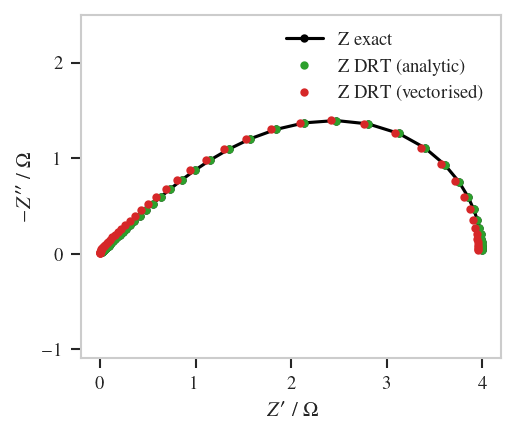

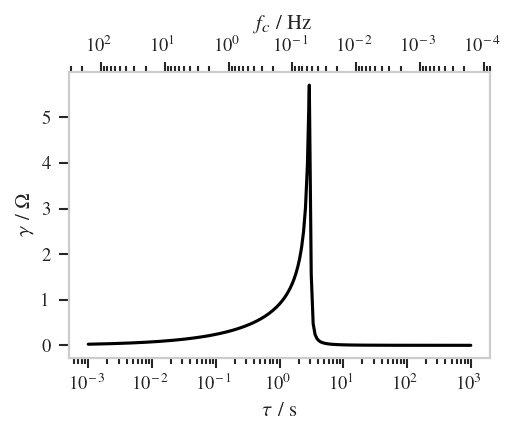

TypeError: ResidualsPlot.add_plot() missing 1 required positional argument: 'residuals'

In [5]:
# Define HN parameters
Z0 = 4.0      # Characteristic impedance (Ohm)
tau0 = 3.0e0      # Characteristic time constant (s)
alpha = 0.99    # Symmetric broadening parameter
beta = 0.5     # Asymmetric broadening parameter

# Create frequency array
f = np.logspace(-3, 3, 50)  # Frequency in Hz decade spacing
omega = 2 * np.pi * f        # Angular frequency in rad/s

# Create time constant array
tau = np.logspace(-3, 3, 200)  # Time constants in s
#tau = 1/omega
# tau = tau[::-1]

# Calculate impedance (analytic HN)
Z = HN_Z(omega, Z0, tau0, alpha, beta)
print(beta)
# Calculate DRT
gamma = HN_DRT(tau, Z0, tau0, alpha, beta)
print(beta)

# Reconstruct impedance from DRT (vectorized gamma)
Z_DRT_vec = reconstruct_Z_DRT(f, gamma, tau=tau, R0=0.0, L0=0.0)

# Reconstruct impedance from DRT (function/callable gamma)
def gamma_func(tau):
    return HN_DRT(tau, Z0, tau0, alpha, beta)
Z_DRT_func = reconstruct_Z_DRT(f, gamma_func, R0=0.0, L0=0.0, quad_opts={'a': -50, 'b': 50, 'epsabs': 1e-9, 'epsrel': 1e-9, 'limit': 100})

print(f"Parameters: Z0={Z0} Ω, τ0={tau0} s, α={alpha}, β={beta}")
print(f"Number of frequency points: {len(f)}")
print(f"Number of time constant points: {len(tau)}")

# Get tab10 colors and names (colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

# initialise plot dictionaries
eis_plot_dict = {}
drt_plot_dict = {}
residuals_plot_dict = {}

EISData_object = EISData(Z=Z, f=f)
EISData_object.label = "Z exact"
eis_plot_dict[EISData_object.label] = {
        "data": EISData(Z=Z, f=f),
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

DRTData_object = DRTData(gamma=gamma, tau=tau)
DRTData_object.label = "DRT exact"
drt_plot_dict[DRTData_object.label] = {
        "data": DRTData(gamma=gamma, tau=tau),
        "plot_kwargs": {"color": colour_dict["black"], "linestyle": "-", "marker": "", "label": DRTData_object.label},
        "plot": True
    }

EISData_object = EISData(Z=Z_DRT_func, f=f)
EISData_object.label = "Z DRT (analytic)"
eis_plot_dict[EISData_object.label] = {
        "data": EISData(Z=Z_DRT_func, f=f),
        "plot_kwargs": {"color": colour_dict["green"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }
residuals = Z_DRT_func - Z
residuals_plot_dict[EISData_object.label] = {
        "data": {'f': f, 'residuals': residuals},
        "plot_kwargs": {"color": colour_dict["green"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

EISData_object = EISData(Z=Z_DRT_vec, f=f)
EISData_object.label = "Z DRT (vectorised)"
eis_plot_dict[EISData_object.label] = {
        "data": EISData(Z=Z_DRT_vec, f=f),
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }
residuals = Z_DRT_vec - Z
residuals_plot_dict[EISData_object.label] = {
        "data": {'f': f, 'residuals': residuals},
        "plot_kwargs": {"color": colour_dict["red"], "linestyle": "", "marker": ".", "label": EISData_object.label},
        "plot": True
    }

#########################
## Create Nyquist Plot ##
#########################
NyquistPlot_object = NyquistPlot(figsize=(3.543, 3), dpi = 150) 
for label, entry in eis_plot_dict.items():
    if entry["plot"]:
        NyquistPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
NyquistPlot_object.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# # NyquistPlot_object.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
# # Best way is to control size using adjustable = "datalim", and then plot invisible points to ensure points are in view if desired. Less useful for cropping.
# # NyquistPlot_object.ax.grid(True)
NyquistPlot_object.add_major_ticks(spacing_x = 1, spacing_y = 1)
# # NyquistPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
NyquistPlot_object.ax.legend()
NyquistPlot_object.fig.tight_layout() # try stop cutting off labels
display(NyquistPlot_object.fig)
# NyquistPlot_object.save("Nyquist.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

#########################
#### Create DRT Plot ####
#########################
DRTPlot_object = DRTPlot(figsize=(3.543, 3), dpi = 150)
for label, entry in drt_plot_dict.items():
    if entry["plot"]:
        DRTPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
DRTPlot_object.add_major_ticks(spacing_y = 1)
# # DRTPlot_object.add_minor_ticks(number_x = 5, number_y = 5)
DRTPlot_object.add_fc_axis() # only use after enforcing DRTPlot_object.ax.set_xlim([0, None]) if desired
DRTPlot_object.fig.tight_layout() # try stop cutting off labels
display(DRTPlot_object.fig)
# DRTPlot_object.save("DRT.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels

###########################
## Create Residuals Plot ##
###########################
ResidualsPlot_object = ResidualsPlot(figsize=(3.543, 3), dpi = 150)
for label, entry in residuals_plot_dict.items():
    if entry["plot"]:
        ResidualsPlot_object.add_plot(entry["data"], **entry["plot_kwargs"])
ResidualsPlot_object.fig.tight_layout() # try stop cutting off labels
display(ResidualsPlot_object.fig)
# ResidualsPlot_object.save("Residuals.svg") # may need to adjust fontsize or use bbox_inches='tight' to stop cutting off labels
#                     #label = "$\lambda$ = " + str(lambda_value_pyDRTtools)+", RMSE = " + str(rmse_res_re_pyDRTtools)) 
#                     label=f"$\\lambda$ = {lambda_value_pyDRTtools:.1e}, RMSE = {rmse_res_re_pyDRTtools:.3e}"
#     )  


# fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.05.06 FB2_FCN_KCl_E620K_1186HCB\1_50ml_20mM_FCN_33rpm_03_GEIS_C04.mpr"
# label = "Cloth 20 mM 33rpm"
# ECData_object = BiologicLoader().load_data(fpath=fpath)
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 2)
# EISData_object = ECData_object.to_EISData()
# EISData_object.label = label
# EISData_array.append(EISData_object)